### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

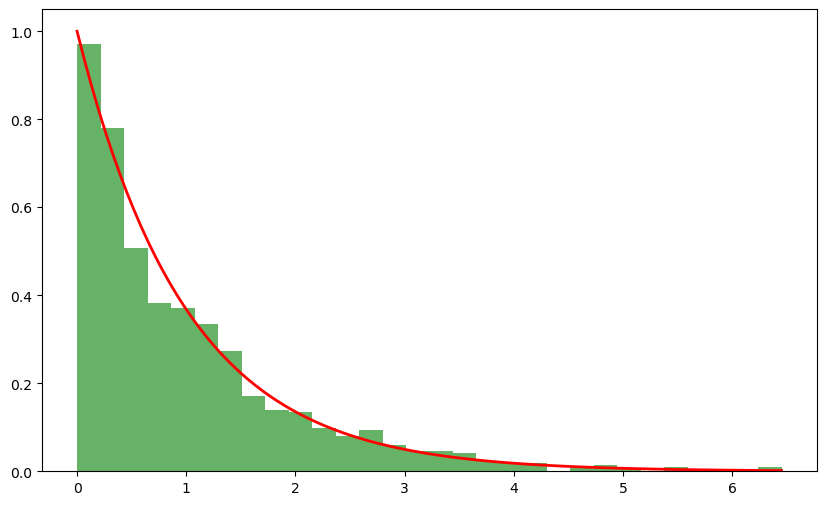

Parametro di forma stimato: 0.9195512994976907


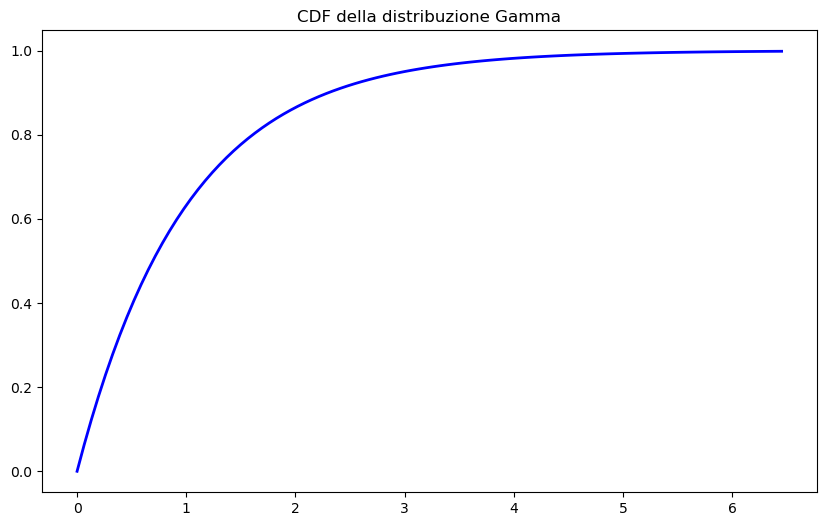

Varianza calcolata: 1.0367413898277453


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

shape_param=1
dist=sp.stats.gamma(shape_param)
data=dist.rvs(size=1000)
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')
x=np.linspace(0, np.max(data), 100)
plt.plot(x, dist.pdf(x), 'r-', lw=2)
plt.show()
fitted_shape, fitted_loc, fitted_scale = sp.stats.gamma.fit(data)
print(f"Parametro di forma stimato: {fitted_shape}")
plt.figure(figsize=(10, 6))
plt.plot(x, dist.cdf(x), 'b-', lw=2)
plt.title("CDF della distribuzione Gamma")
plt.show()
variance=np.var(data)
print(f"Varianza calcolata: {variance}")

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

Max Temp - MAE: 2.58, RMSE: 2.96
Min Temp - MAE: 7.52, RMSE: 8.53


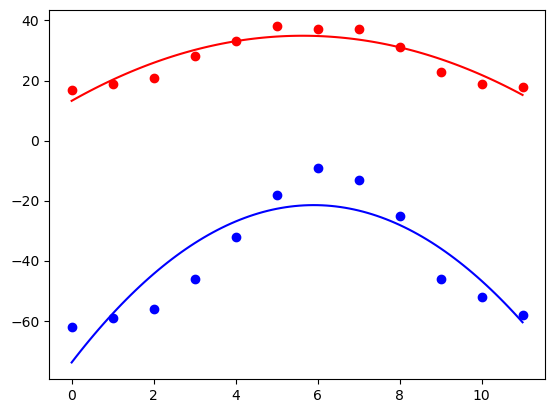

In [6]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

mesi=np.arange(12)
coeff_max=np.polyfit(mesi, temp_max, 2)
coeff_min=np.polyfit(mesi, temp_min, 2)
fit_max=np.polyval(coeff_max, mesi)
fit_min=np.polyval(coeff_min, mesi)
mae_max=np.mean(np.abs(temp_max - fit_max))
rmse_max=np.sqrt(np.mean((temp_max - fit_max)**2))
mae_min=np.mean(np.abs(temp_min - fit_min))
rmse_min=np.sqrt(np.mean((temp_min - fit_min)**2))
print(f"Max Temp - MAE: {mae_max:.2f}, RMSE: {rmse_max:.2f}")
print(f"Min Temp - MAE: {mae_min:.2f}, RMSE: {rmse_min:.2f}")
x_smooth=np.linspace(0, 11, 100)
plt.plot(mesi, temp_max, 'ro')
plt.plot(x_smooth, np.polyval(coeff_max, x_smooth), 'r-')
plt.plot(mesi, temp_min, 'bo')
plt.plot(x_smooth, np.polyval(coeff_min, x_smooth), 'b-')
plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

Coefficiente angolare (m): -0.0412
Intercetta (q): 29.5999
MAE: 2.61
RMSE: 3.15


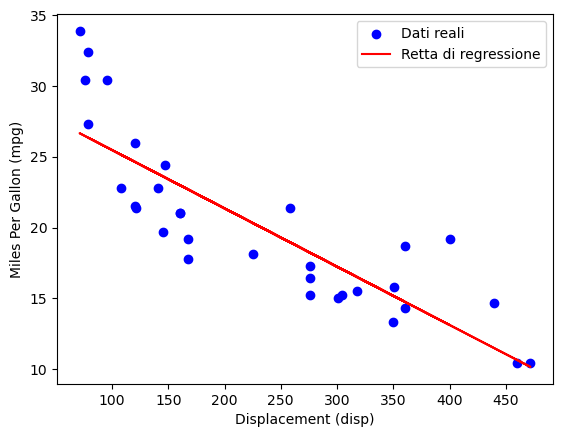

In [7]:
import pandas as pd
# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')
# Display the dataframe
df
import numpy as np
import matplotlib.pyplot as plt

x=df['disp']
y=df['mpg']
m, q=np.polyfit(x, y, 1)
y_pred=m * x + q
mae=np.mean(np.abs(y - y_pred))
rmse=np.sqrt(np.mean((y - y_pred)**2))
print(f"Coefficiente angolare (m): {m:.4f}")
print(f"Intercetta (q): {q:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
plt.scatter(x, y, color='blue', label='Dati reali')
plt.plot(x, y_pred, color='red', label='Retta di regressione')
plt.xlabel('Displacement (disp)')
plt.ylabel('Miles Per Gallon (mpg)')
plt.legend()
plt.show()